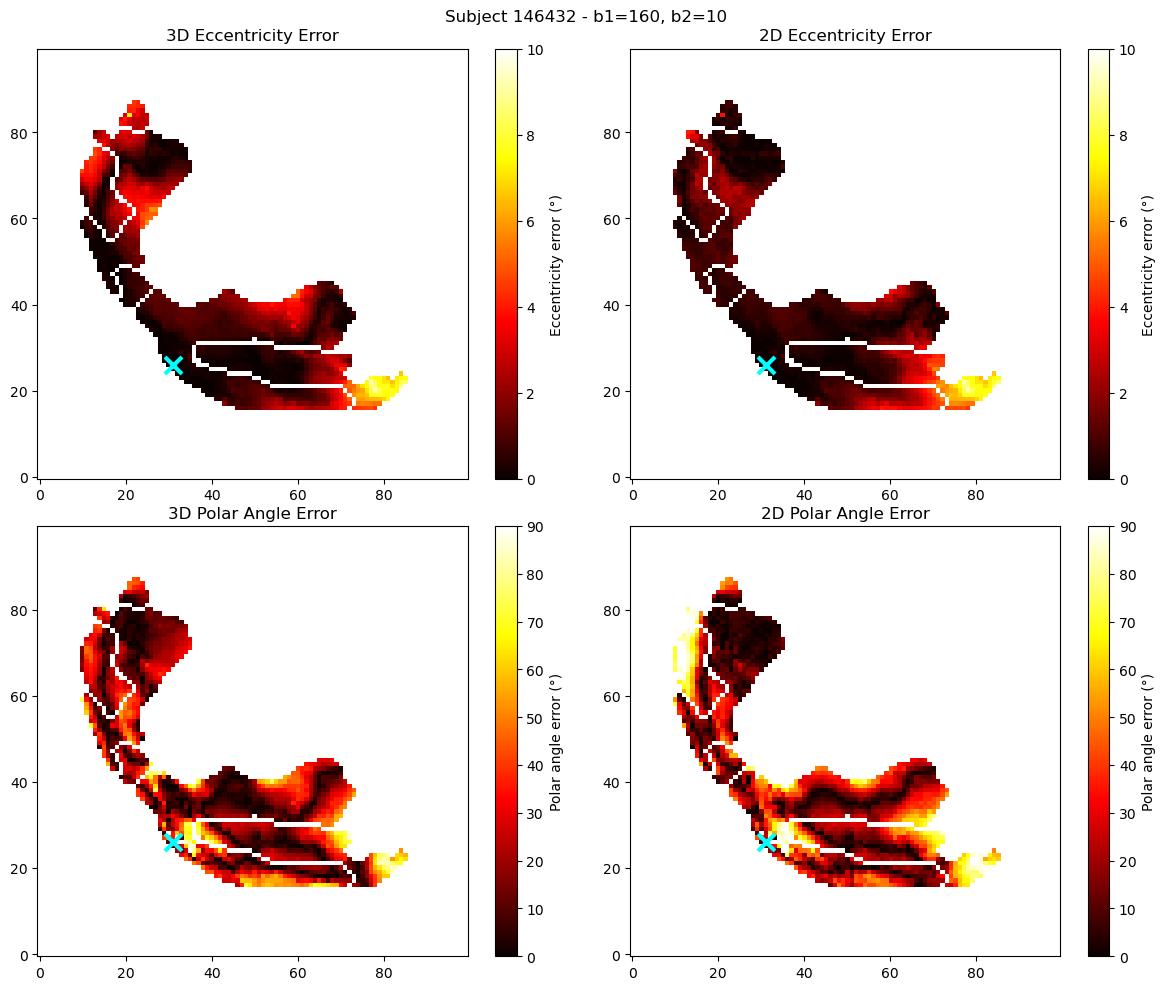

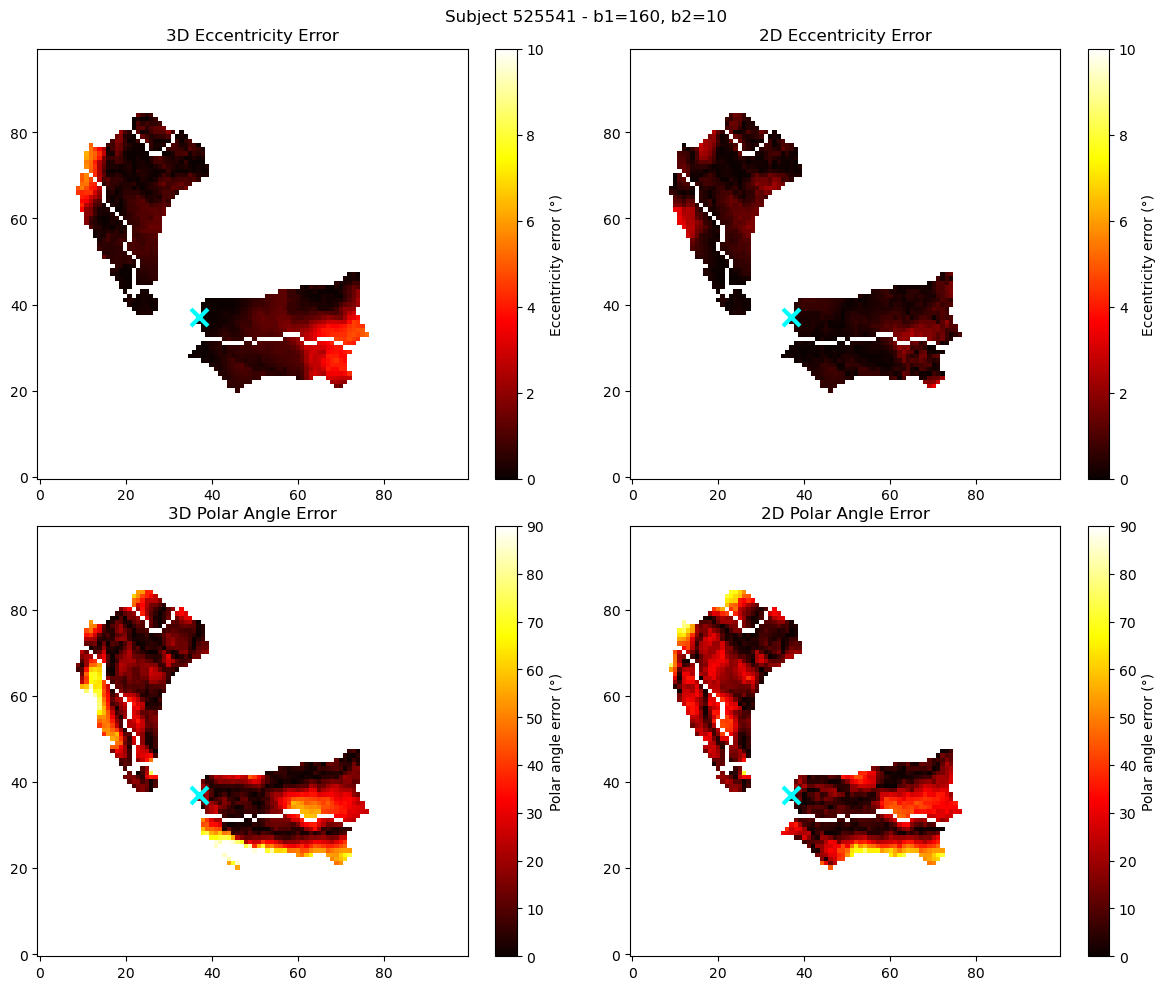

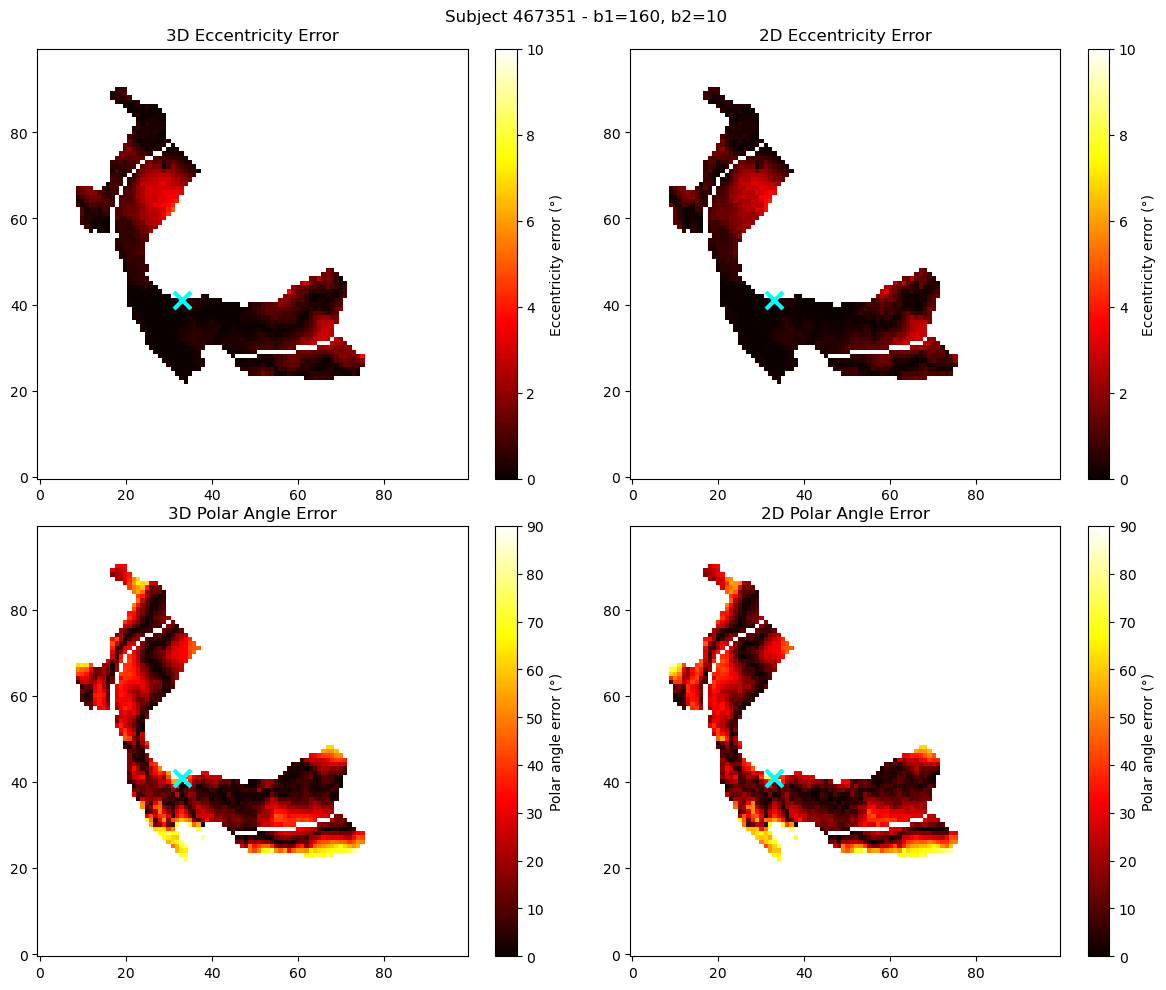

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import scipy.io as sio
import functions.dstools as dst

loadDir = r'\\storage.erc.monash.edu\shares\MNHS-dshi0006\VariabilityEarlyVisualCortex'

# Subjects to plot
subject_id = ['146432', '525541', '467351']

# Parameter combination
b1 = 160
b2 = 10

for x in subject_id:

    paths = [
        os.path.join(loadDir, x),
        os.path.join(loadDir, x + '(done)')
    ]

    thisDir = None

    for candidate in paths:

        border_path = os.path.join(
            candidate,
            f'arealBorder_{x}.mat'
        )

        if os.path.exists(border_path):
            thisDir = candidate
            break

    if thisDir is None:
        print(f'No valid directory found for {x}. Skipping.')
        continue

    arealBorders = sio.loadmat(
        os.path.join(thisDir, f'arealBorder_{x}.mat')
    )

    maltitude = arealBorders['grid_altitude_i']
    mazimuth = arealBorders['grid_azimuth_i']

    shape2d = arealBorders['areaMatrix'][0][0].shape

    # Empirical retinotopy
    retinotopy = np.column_stack((
        mazimuth.ravel(order='F'),
        maltitude.ravel(order='F')
    ))

    nAreas = len(arealBorders['areaMatrix'][0])

    mask_idx = []

    for iarea in range(nAreas):

        mask_sub = np.argwhere(
            arealBorders['areaMatrix'][0][iarea] == 1
        )

        idx = dst.sub2ind(
            shape2d,
            mask_sub[:, 0],
            mask_sub[:, 1]
        )

        mask_idx.append(idx)

    # V2 + V3
    varIdx = [1, 2]

    mask_var_idx = np.concatenate([
        mask_idx[index]
        for index in varIdx
    ])

    mask_var_sub = np.vstack([
        np.argwhere(
            arealBorders['areaMatrix'][0][index] == 1
        )
        for index in varIdx
    ])

    mat_file_path = os.path.join(
        thisDir,
        f'summary_V+D_{x}_b1_{b1}_b2_{b2}_vs.mat'
    )

    if not os.path.exists(mat_file_path):

        print(
            f'MAT file missing for {x}, '
            f'b1={b1}, b2={b2}. Skipping.'
        )

        continue

    mat_contents = sio.loadmat(mat_file_path)

    if 'result_v' not in mat_contents:

        print(f"'result_v' missing for {x}. Skipping.")
        continue

    if 'result_s' not in mat_contents:

        print(f"'result_s' missing for {x}. Skipping.")
        continue

    result_v = np.asarray(
        mat_contents['result_v'][0, 0]
    ).squeeze()

    result_s = np.asarray(
        mat_contents['result_s'][0, 0]
    ).squeeze()

    empirical_ecc, empirical_pa = dst.cartesian_to_polar(
        retinotopy[:, 0],
        retinotopy[:, 1]
    )

    result_v_ecc, result_v_pa = dst.cartesian_to_polar(
        result_v[:, 0],
        result_v[:, 1]
    )

    result_s_ecc, result_s_pa = dst.cartesian_to_polar(
        result_s[:, 0],
        result_s[:, 1]
    )

    empirical_ecc = np.asarray(
        empirical_ecc[mask_var_idx]
    )

    empirical_pa = np.asarray(
        empirical_pa[mask_var_idx]
    )

    #errors
    # Eccentricity
    error_ecc_3d = np.abs(
        result_v_ecc - empirical_ecc
    )

    error_ecc_2d = np.abs(
        result_s_ecc - empirical_ecc
    )

    # Polar angle
    #shortest angular distance
    #
    error_pa_3d = np.abs(
        (result_v_pa - empirical_pa + 180) % 360 - 180
    )

    error_pa_2d = np.abs(
        (result_s_pa - empirical_pa + 180) % 360 - 180
    )

    #error maps
    error_ecc_map_3d = np.full(
        shape2d,
        np.nan
    )

    error_ecc_map_2d = np.full(
        shape2d,
        np.nan
    )

    error_pa_map_3d = np.full(
        shape2d,
        np.nan
    )

    error_pa_map_2d = np.full(
        shape2d,
        np.nan
    )


    # Put errors back into cortical map
    error_ecc_map_3d[
        mask_var_sub[:, 0],
        mask_var_sub[:, 1]
    ] = error_ecc_3d

    error_ecc_map_2d[
        mask_var_sub[:, 0],
        mask_var_sub[:, 1]
    ] = error_ecc_2d

    error_pa_map_3d[
        mask_var_sub[:, 0],
        mask_var_sub[:, 1]
    ] = error_pa_3d

    error_pa_map_2d[
        mask_var_sub[:, 0],
        mask_var_sub[:, 1]
    ] = error_pa_2d

    #fovea
    all_ecc = np.asarray(
        empirical_ecc
    )

    fovea_local_idx = np.argmin(all_ecc)

    fovea_sub = mask_var_sub[fovea_local_idx]
    #plotting

    fig, ax = plt.subplots(
        2,
        2,
        figsize=(12, 10)
    )

    im1 = ax[0, 0].imshow(
        error_ecc_map_3d,
        origin='lower',
        cmap='hot',
        vmin=0,
        vmax=10
    )

    ax[0, 0].set_title('3D Eccentricity Error')

    im2 = ax[0, 1].imshow(
        error_ecc_map_2d,
        origin='lower',
        cmap='hot',
        vmin=0,
        vmax=10
    )

    ax[0, 1].set_title('2D Eccentricity Error')

    im3 = ax[1, 0].imshow(
        error_pa_map_3d,
        origin='lower',
        cmap='hot',
        vmin=0,
        vmax=90
    )

    ax[1, 0].set_title('3D Polar Angle Error')

    im4 = ax[1, 1].imshow(
        error_pa_map_2d,
        origin='lower',
        cmap='hot',
        vmin=0,
        vmax=90
    )

    ax[1, 1].set_title('2D Polar Angle Error')

    for axis in ax.flat:

        axis.scatter(
            fovea_sub[1],
            fovea_sub[0],
            marker='x',
            c='cyan',
            s=150,
            linewidths=3
        )

    fig.colorbar(
        im1,
        ax=ax[0, 0],
        label='Eccentricity error (°)'
    )

    fig.colorbar(
        im2,
        ax=ax[0, 1],
        label='Eccentricity error (°)'
    )

    fig.colorbar(
        im3,
        ax=ax[1, 0],
        label='Polar angle error (°)'
    )

    fig.colorbar(
        im4,
        ax=ax[1, 1],
        label='Polar angle error (°)'
    )


    plt.suptitle(
        f'Subject {x} - b1={b1}, b2={b2}'
    )

    plt.tight_layout()
    plt.show()

visualising empirical and simulated data

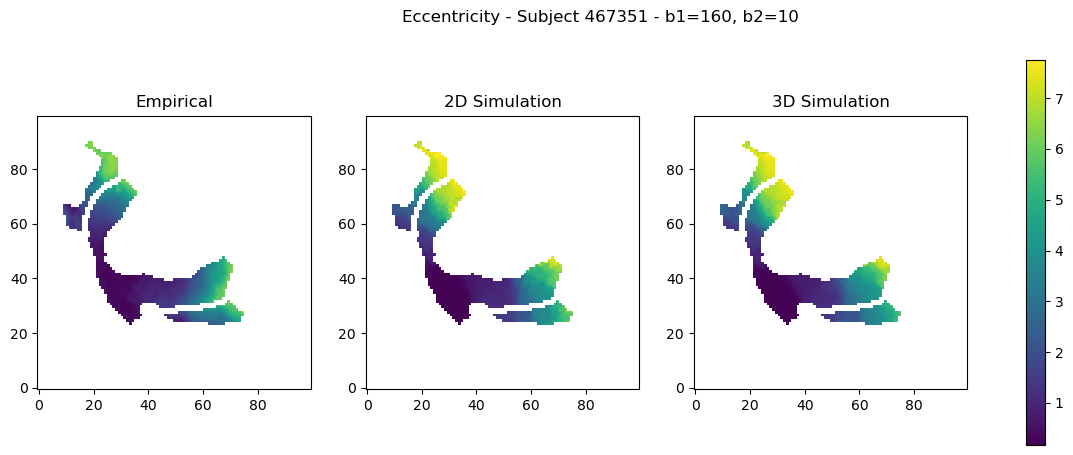

In [9]:
ecc_map_2d = np.full((100, 100), np.nan)

ecc_map_2d[
    mask_var_sub[:,0],
    mask_var_sub[:,1]
] = result_s_ecc

ecc_map_3d = np.full((100, 100), np.nan)

ecc_map_3d[
    mask_var_sub[:,0],
    mask_var_sub[:,1]
] = result_v_ecc

empirical_ecc_map = np.full((100, 100), np.nan)

empirical_ecc_map[
    mask_var_sub[:,0],
    mask_var_sub[:,1]
] = empirical_ecc

fig, ax = plt.subplots(1,3, figsize=(15,5))

# plt.contour(empirical_ecc_map, levels=np.arange(1, 12, 1), colors='k')
ax[0].imshow(empirical_ecc_map, origin='lower', cmap='viridis')
ax[0].set_title('Empirical')

im = ax[1].imshow(ecc_map_2d, origin='lower', cmap='viridis')
ax[1].set_title('2D Simulation')
# plt.contour(ecc_map, levels=np.arange(1, 12, 1), colors='k')

im = ax[2].imshow(ecc_map_3d, origin='lower', cmap='viridis')
ax[2].set_title('3D Simulation')
# plt.contour(ecc_map, levels=np.arange(1, 12, 1), colors='k')

plt.suptitle(f'Eccentricity - Subject {x} - b1={b1}, b2={b2}')

plt.colorbar(im, ax=ax)

Eccentricity vs error (using isopolar bands)

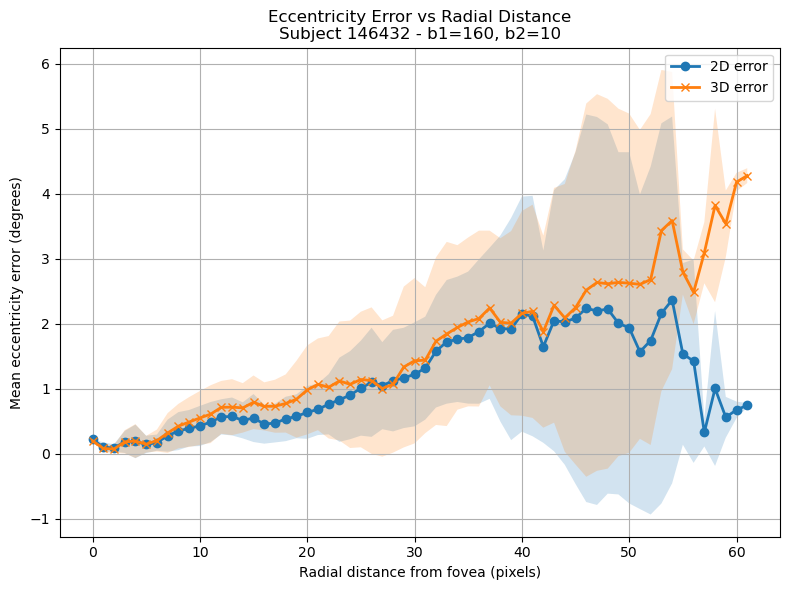

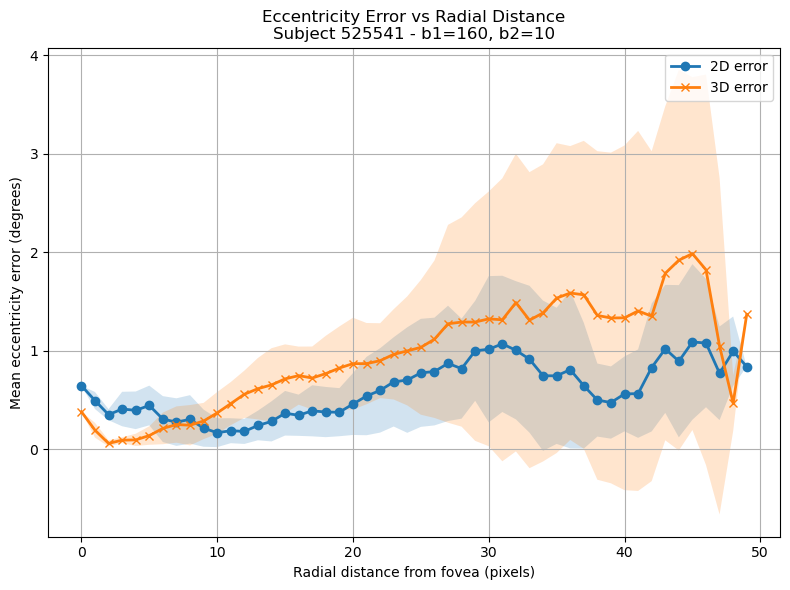

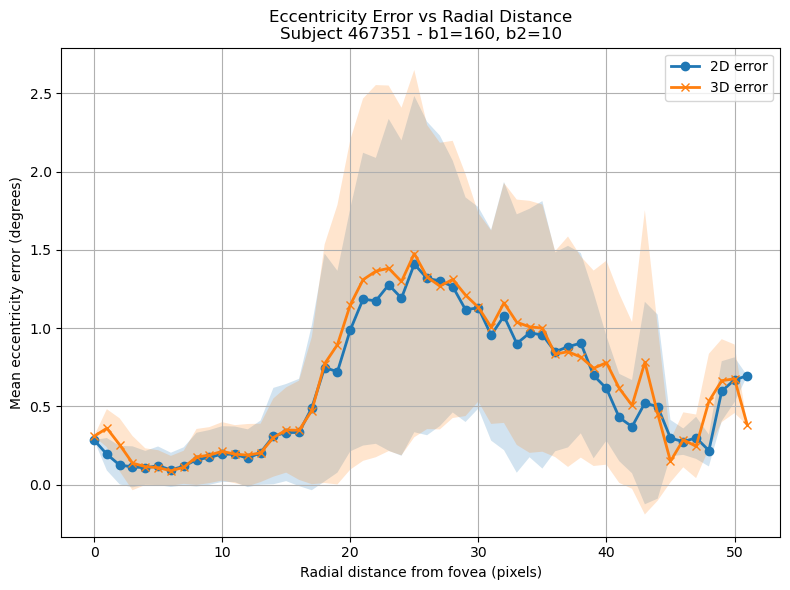

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import functions.dstools as dst
import os
import scipy.io as sio

loadDir = r'\\storage.erc.monash.edu\shares\MNHS-dshi0006\VariabilityEarlyVisualCortex'

subject_id = ['146432', '525541', '467351']

missing_id = []

b1 = 160
b2 = 10

for x in subject_id:
    paths = [
        os.path.join(loadDir, x),
        os.path.join(loadDir, x + '(done)')
    ]

    thisDir = None

    for candidate in paths:

        border_path = os.path.join(
            candidate,
            f'arealBorder_{x}.mat'
        )

        if os.path.exists(border_path):
            thisDir = candidate
            break

    if thisDir is None:
        missing_id.append(x)
        print(f"Missing arealBorder file for {x}")
        continue

    arealBorders = sio.loadmat(
        os.path.join(
            thisDir,
            f'arealBorder_{x}.mat'
        )
    )

    maltitude = arealBorders['grid_altitude_i']
    mazimuth = arealBorders['grid_azimuth_i']

    shape2d = arealBorders['areaMatrix'][0][0].shape

    retinotopy = np.column_stack((
        mazimuth.ravel(order='F'),
        maltitude.ravel(order='F')
    ))

    nAreas = len(arealBorders['areaMatrix'][0])

    mask_sub = [None] * nAreas
    mask_idx = [None] * nAreas

    for iarea in range(nAreas):

        mask_sub[iarea] = np.argwhere(
            arealBorders['areaMatrix'][0][iarea] == 1
        )

        mask_idx[iarea] = dst.sub2ind(
            shape2d,
            mask_sub[iarea][:, 0],
            mask_sub[iarea][:, 1]
        )

    varIdx = [1, 2]

    mask_var_idx = np.concatenate([
        mask_idx[index]
        for index in varIdx
    ])

    mask_var_sub = np.vstack([
        mask_sub[index]
        for index in varIdx
    ])

    mask_all_idx = np.concatenate(mask_idx)

    mask_all_sub = np.vstack(mask_sub)

    mat_file_path = os.path.join(
        thisDir,
        f'summary_V+D_{x}_b1_{b1}_b2_{b2}_vs.mat'
    )

    if not os.path.exists(mat_file_path):

        print(
            f"MAT file not found for {x}, "
            f"b1={b1}, b2={b2}"
        )

        missing_id.append((x, b1, b2))
        continue


    mat_contents = sio.loadmat(mat_file_path)

    if 'result_v' not in mat_contents:

        print(
            f"'result_v' missing for {x}, "
            f"b1={b1}, b2={b2}"
        )

        continue


    if 'result_s' not in mat_contents:

        print(
            f"'result_s' missing for {x}, "
            f"b1={b1}, b2={b2}"
        )

        continue

    result_v = np.asarray(
        mat_contents['result_v'][0, 0]
    ).squeeze()

    result_s = np.asarray(
        mat_contents['result_s'][0, 0]
    ).squeeze()

    # Empirical
    empirical_ecc, empirical_pa = dst.cartesian_to_polar(
        retinotopy[:, 0],
        retinotopy[:, 1]
    )


    # 3D simulation
    result_v_ecc, result_v_pa = dst.cartesian_to_polar(
        result_v[:, 0],
        result_v[:, 1]
    )


    # 2D simulation
    result_s_ecc, result_s_pa = dst.cartesian_to_polar(
        result_s[:, 0],
        result_s[:, 1]
    )

    empirical_ecc = np.asarray(
        empirical_ecc[mask_var_idx]
    )

    result_v_ecc = np.asarray(
        result_v_ecc
    )

    result_s_ecc = np.asarray(
        result_s_ecc
    )

    error_3d = np.abs(
        result_v_ecc - empirical_ecc
    )

    error_2d = np.abs(
        result_s_ecc - empirical_ecc
    )

    error_map_3d = np.full(
        shape2d,
        np.nan
    )

    error_map_2d = np.full(
        shape2d,
        np.nan
    )


    error_map_3d[
        mask_var_sub[:, 0],
        mask_var_sub[:, 1]
    ] = error_3d


    error_map_2d[
        mask_var_sub[:, 0],
        mask_var_sub[:, 1]
    ] = error_2d

    all_ecc = np.asarray(
        empirical_ecc
    )

    valid = np.isfinite(all_ecc)

    fovea_local_idx = np.where(valid)[0][
        np.argmin(all_ecc[valid])
    ]

    fovea_sub = mask_var_sub[fovea_local_idx]

    rows, cols = np.indices(shape2d)

    radial_dist = np.sqrt(
        (rows - fovea_sub[0])**2 +
        (cols - fovea_sub[1])**2
    )


    # Integer radial bands
    radial_band = np.floor(
        radial_dist
    ).astype(int)

    max_band = radial_band.max()

    mean_error_2d = np.full(
        max_band + 1,
        np.nan
    )

    std_error_2d = np.full(
        max_band + 1,
        np.nan
    )

    mean_error_3d = np.full(
        max_band + 1,
        np.nan
    )

    std_error_3d = np.full(
        max_band + 1,
        np.nan
    )


    for b in range(max_band + 1):

        # Pixels in this radial band
        band_mask = (
            radial_band == b
        )

        # 2D valid pixels
        valid_2d = (
            band_mask &
            np.isfinite(error_map_2d)
        )

        # 3D valid pixels
        valid_3d = (
            band_mask &
            np.isfinite(error_map_3d)
        )


        if np.any(valid_2d):

            mean_error_2d[b] = np.mean(
                error_map_2d[valid_2d]
            )

            std_error_2d[b] = np.std(
                error_map_2d[valid_2d]
            )


        if np.any(valid_3d):

            mean_error_3d[b] = np.mean(
                error_map_3d[valid_3d]
            )

            std_error_3d[b] = np.std(
                error_map_3d[valid_3d]
            )

    radial_x = np.arange(
        len(mean_error_2d)
    )


    plt.figure(figsize=(8, 6))


    # 2D
    plt.plot(
        radial_x,
        mean_error_2d,
        '-o',
        lw=2,
        label='2D error'
    )

    plt.fill_between(
        radial_x,
        mean_error_2d - std_error_2d,
        mean_error_2d + std_error_2d,
        alpha=0.2
    )


    # 3D
    plt.plot(
        radial_x,
        mean_error_3d,
        '-x',
        lw=2,
        label='3D error'
    )

    plt.fill_between(
        radial_x,
        mean_error_3d - std_error_3d,
        mean_error_3d + std_error_3d,
        alpha=0.2
    )


    plt.xlabel(
        'Radial distance from fovea (pixels)'
    )

    plt.ylabel(
        'Mean eccentricity error (degrees)'
    )

    plt.title(
        f'Eccentricity Error vs Radial Distance\n'
        f'Subject {x} - b1={b1}, b2={b2}'
    )

    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

Average across all subjects

In [ ]:
import os
os.chdir(r'c:\Users\61439\Variability_Early_Visual_Cortex_new\VariabilityEarlyVisualCortex') 
loadDir = r'\\storage.erc.monash.edu\shares\MNHS-dshi0006\VariabilityEarlyVisualCortex';
import scipy.io as sio
import numpy as np
import matplotlib.pyplot as plt
import functions.dstools as dst
parent_dir = os.getcwd()

# subject list
list_path = os.path.join(parent_dir, 'list_subj.txt')

with open(list_path, 'r') as f:
    subject_id = [line.strip() for line in f if line.strip()]

# subject_id  = ['146432', '525541', '467351']
all_mean_error_2d = []
all_std_error_2d = []
all_mean_error_3d = []
all_std_error_3d = []
n = 0
missing_id = []

for x in subject_id:
    paths = [
    os.path.join(loadDir, x + '(done)'),
    os.path.join(loadDir, x)
]
    thisDir = None

    for candidate in paths:
        border_path = os.path.join(candidate, f'arealBorder_{x}.mat')

        if os.path.exists(border_path):
            thisDir = candidate
            arealBorders = sio.loadmat(border_path)
            break

    if thisDir is None:
        missing_id.append(x)
        print(f"Missing required files for {x}")
        continue

    maltitude = arealBorders['grid_altitude_i'] 
    mazimuth = arealBorders['grid_azimuth_i']
    shape2d = arealBorders['areaMatrix'][0][0].shape
    retinotopy = np.column_stack((mazimuth.ravel(order='F'), maltitude.ravel(order='F')))
    
    #check against main code
    nAreas = len(arealBorders['areaMatrix'][0])
    mask_sub = [None]*nAreas
    mask_idx = [None]*nAreas
    for iarea in range(0, nAreas):
        mask_sub[iarea] = np.argwhere(arealBorders['areaMatrix'][0][iarea] == 1) #[y,x]
        mask_idx[iarea] = dst.sub2ind(shape2d, mask_sub[iarea][:,0], mask_sub[iarea][:,1]) #[v1 pixels x 1]
    
    fixIdx = [0]
    varIdx = [1, 2]
    mask_var_idx = np.concatenate([mask_idx[index] for index in varIdx])
    mask_var_sub = np.vstack([mask_sub[index] for index in varIdx])
    mask_fix_idx = np.concatenate([mask_idx[index] for index in fixIdx])
    mask_fix_sub = np.vstack([mask_sub[index] for index in fixIdx])
    mask_all_idx = np.concatenate([mask_idx[index] for index in range(nAreas)])
    mask_all_sub = np.vstack([mask_sub[index] for index in range(nAreas)])
    # for i in range(len(b1_b2_vals)):
    #     for j in range(len(b1_b2_vals)):
    b1 = 10
    b2 = 160
    # b1 = b1_b2_vals[i]
    # b2 = b1_b2_vals[j]
    
    # print(f"Processing {x}, b1={b1}, b2={b2}")
    # Load the .mat file
    mat_file_path = os.path.join(thisDir, f'summary_V+D_{x}_b1_{b1}_b2_{b2}_vs.mat')
    if not os.path.exists(mat_file_path):
        print(f"MAT file not found for b1={b1}, b2={b2}, skipping.")
        continue
    mat_contents = sio.loadmat(mat_file_path)

    # Extract the results and pearson correlation coefficient values of the simulation
    if 'result_v' not in mat_contents:
        print(f"'result_v' missing for {x}, b1={b1}, b2={b2}")
        missing_id.append((x, b1, b2))
        continue
    if 'result_s' not in mat_contents:
        print(f"'result_s' missing for {x}, b1={b1}, b2={b2}")
        missing_id.append((x, b1, b2))
        continue

    result = mat_contents['result_v'][0,0]
    result = np.asarray(result)
    result = np.squeeze(result)

    result_flat = mat_contents['result_s'][0,0]
    result_flat = np.asarray(result_flat)
    result_flat = np.squeeze(result_flat)

    #empirical data
    retinotopy_ecc, retinotopy_pa = dst.cartesian_to_polar(retinotopy[:,0],retinotopy[:,1])
    retinotopy_pol = np.column_stack((retinotopy_ecc,retinotopy_pa)) #[ecc, pa] in [deg]
    empirical_ecc = retinotopy_pol[mask_var_idx, 0]

    #simulation data
    result_flat_ecc, result_flat_pa = dst.cartesian_to_polar(result_flat[:,0],result_flat[:,1])
    result_ecc, result_pa = dst.cartesian_to_polar(result[:,0],result[:,1])

    #3d error
    error_3d = np.abs((result_ecc - empirical_ecc))

    #2d error
    error_2d = np.abs((result_flat_ecc - empirical_ecc))
    all_ecc = retinotopy_pol[mask_all_idx, 0]

    if all_ecc.size == 0:
        print(f"No valid eccentricity data for subject {x}")
        continue

    fovea_sub = mask_all_sub[np.argmin(all_ecc)]

    # distance of each pixel from the fovea
    rows, cols = np.indices((100, 100))

    dist = np.sqrt(
        (rows - fovea_sub[0])**2 +
        (cols - fovea_sub[1])**2
    )

    band_width = 1  # pixels
    radial_band = np.floor(dist / band_width).astype(int)

    # Distance of every pixel from the fovea
    rows, cols = np.indices(error_map_2d.shape)

    radial_dist = np.sqrt(
        (rows - fovea_sub[0])**2 +
        (cols - fovea_sub[1])**2
    )

    # Integer radial bands (1-pixel wide)
    radial_band = np.floor(radial_dist).astype(int)

    # Calculate mean error in each band
    max_band = radial_band.max()

    mean_error_2d = np.full(max_band + 1, np.nan)
    std_error_2d = np.full(max_band + 1, np.nan)
    n_points_2d = np.zeros(max_band + 1)
    mean_error_3d = np.full(max_band + 1, np.nan)
    std_error_3d = np.full(max_band + 1, np.nan)
    n_points_3d = np.zeros(max_band + 1)

    for b in range(max_band + 1):

        # mask = (radial_band == b) & (~np.isnan(error_map_2d))
        mask2d = (radial_band == b) & (~np.isnan(error_map_2d))
        mask3d = (radial_band == b) & (~np.isnan(error_map_3d))

        if np.any(mask2d):
            mean_error_2d[b] = np.mean(error_map_2d[mask2d])
            std_error_2d[b] = np.std(error_map_2d[mask2d])
            n_points_2d[b] = np.sum(mask2d)

        if np.any(mask3d):
            mean_error_3d[b] = np.mean(error_map_3d[mask3d])
            std_error_3d[b] = np.std(error_map_3d[mask3d])
            n_points_3d[b] = np.sum(mask3d)

    all_mean_error_2d.append(mean_error_2d)
    all_std_error_2d.append(std_error_2d)
    all_mean_error_3d.append(mean_error_3d)
    all_std_error_3d.append(std_error_3d)
    n +=1

max_len = max(len(curve) for curve in all_mean_error_2d)

all_mean_2d = np.full((len(all_mean_error_2d), max_len), np.nan)
all_mean_3d = np.full((len(all_mean_error_3d), max_len), np.nan)

for i, curve in enumerate(all_mean_error_2d):
    all_mean_2d[i, :len(curve)] = curve

for i, curve in enumerate(all_mean_error_3d):
    all_mean_3d[i, :len(curve)] = curve

group_mean_2d = np.nanmean(all_mean_2d, axis=0)
group_std_2d  = np.nanstd(all_mean_2d, axis=0)

group_mean_3d = np.nanmean(all_mean_3d, axis=0)
group_std_3d  = np.nanstd(all_mean_3d, axis=0)

n_subjects_per_band = np.sum(~np.isnan(all_mean_2d), axis=0)
threshold = n

valid = n_subjects_per_band >= threshold

plt.figure(figsize=(8,6))

# plt.plot(np.where(valid)[0], group_mean_2d[valid], '-o', lw=2)
plt.plot(group_mean_2d, '-o', lw=2)
plt.xlabel('Radial distance from fovea (pixels)')
plt.ylabel('Mean error')
plt.fill_between(np.arange(len(group_mean_2d)), group_mean_2d - group_std_2d, group_mean_2d + group_std_2d, alpha=0.2)

# plt.plot(np.where(valid)[0], group_mean_3d[valid], '-x', lw=2)
plt.plot(group_mean_3d, '-x', lw=2)
plt.xlabel('Radial distance from fovea (pixels)')
plt.ylabel('Mean error')
plt.fill_between(np.arange(len(group_mean_3d)), group_mean_3d - group_std_3d, group_mean_3d + group_std_3d, alpha=0.2)
plt.legend(['2D error', '2D stdev', '3D error', '3D stdev'])
plt.title('Average error vs radial distance across subjects - b1=' + str(b1) + ', b2=' + str(b2))

plt.grid(True)

plt.tight_layout()
plt.show()

MAT file not found for b1=10, b2=160, skipping.
MAT file not found for b1=10, b2=160, skipping.
MAT file not found for b1=10, b2=160, skipping.
MAT file not found for b1=10, b2=160, skipping.
MAT file not found for b1=10, b2=160, skipping.
MAT file not found for b1=10, b2=160, skipping.
MAT file not found for b1=10, b2=160, skipping.


NameError: name 'error_map_2d' is not defined

: 

'result' missing for 102816, b1=10, b2=160
'result' missing for 104416, b1=10, b2=160
'result' missing for 105923, b1=10, b2=160
'result' missing for 108323, b1=10, b2=160
'result' missing for 109123, b1=10, b2=160
MAT file not found for b1=10, b2=160, skipping.
MAT file not found for b1=10, b2=160, skipping.
MAT file not found for b1=10, b2=160, skipping.
MAT file not found for b1=10, b2=160, skipping.
No valid eccentricity data for subject 169343
No valid eccentricity data for subject 169444
Missing required files for 187345
MAT file not found for b1=10, b2=160, skipping.
Missing required files for 196144
MAT file not found for b1=10, b2=160, skipping.
MAT file not found for b1=10, b2=160, skipping.
MAT file not found for b1=10, b2=160, skipping.
MAT file not found for b1=10, b2=160, skipping.
MAT file not found for b1=10, b2=160, skipping.
MAT file not found for b1=10, b2=160, skipping.
MAT file not found for b1=10, b2=160, skipping.
MAT file not found for b1=10, b2=160, skipping.


C:\Users\61439\AppData\Local\Temp\ipykernel_43548\2785579593.py:267: RuntimeWarning: Mean of empty slice
  group_mean_2d_dorsal = np.nanmean(all_mean_2d_dorsal, axis=0)
C:\Users\61439\AppData\Local\Temp\ipykernel_43548\2785579593.py:270: RuntimeWarning: Mean of empty slice
  group_mean_2d_ventral = np.nanmean(all_mean_2d_ventral, axis=0)
C:\Users\61439\AppData\Local\Temp\ipykernel_43548\2785579593.py:273: RuntimeWarning: Mean of empty slice
  group_mean_3d_dorsal = np.nanmean(all_mean_3d_dorsal, axis=0)
C:\Users\61439\AppData\Local\Temp\ipykernel_43548\2785579593.py:276: RuntimeWarning: Mean of empty slice
  group_mean_3d_ventral = np.nanmean(all_mean_3d_ventral, axis=0)


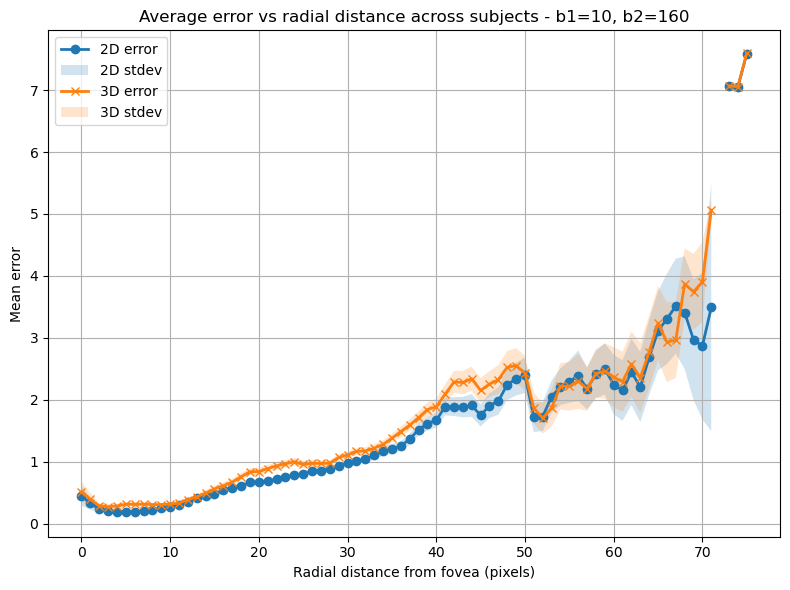

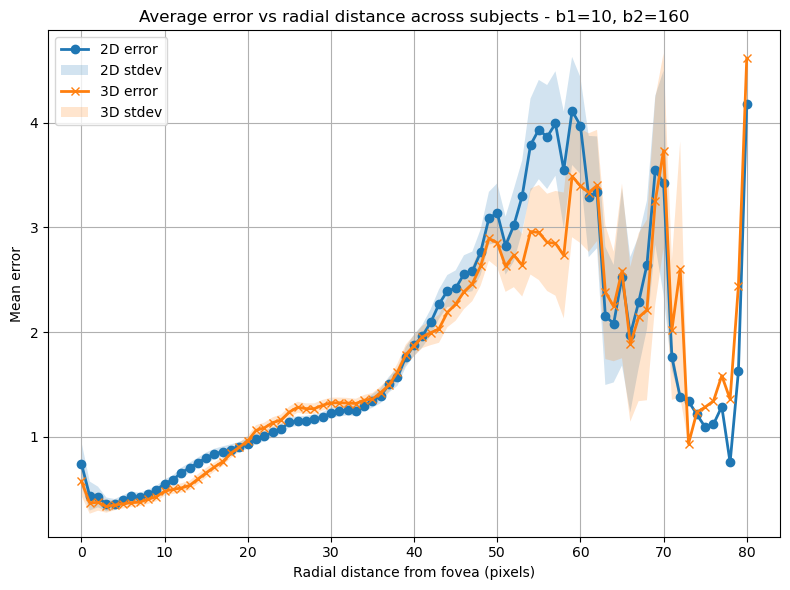

In [22]:
# Dorsal vs ventral error analysis

# First, average dorsal error (2D vs 3D) across subjects

parent_dir = os.getcwd()

# subject list
list_path = os.path.join(parent_dir, 'list_subj.txt')

with open(list_path, 'r') as f:
    subject_id = [line.strip() for line in f if line.strip()]

# subject_id  = ['146432', '525541', '467351']
all_mean_error_2d_dorsal = []
all_mean_error_2d_ventral = []
all_std_error_2d_dorsal = []
all_std_error_2d_ventral = []
all_mean_error_3d_dorsal = []
all_mean_error_3d_ventral = []
all_std_error_3d_dorsal = []
all_std_error_3d_ventral  = []
n = 0

for x in subject_id:
    paths = [
    os.path.join(loadDir, x + '(done)'),
    os.path.join(loadDir, x)
]
    thisDir = None

    for candidate in paths:
        border_path = os.path.join(candidate, f'arealBorder_{x}.mat')

        if os.path.exists(border_path):
            thisDir = candidate
            arealBorders = sio.loadmat(border_path)
            break

    if thisDir is None:
        missing_id.append(x)
        print(f"Missing required files for {x}")
        continue

    maltitude = arealBorders['grid_altitude_i'] 
    mazimuth = arealBorders['grid_azimuth_i']
    shape2d = arealBorders['areaMatrix'][0][0].shape
    retinotopy = np.column_stack((mazimuth.ravel(order='F'), maltitude.ravel(order='F')))
    
    final_mask_L_idx = retinotopyData['final_mask_L_idx'].astype(int)[0] 
    final_mask_L_d_idx = retinotopyData['final_mask_L_d_idx'].astype(int)[0] 
    a,b = dst.ind2sub(shape2d, final_mask_L_idx) 
    final_mask_L_sub = np.column_stack((a,b)).astype(int) #[y,x] 
    
    nAreas = len(arealBorders['areaMatrix'][0])
    mask_sub = [None]*nAreas
    mask_idx = [None]*nAreas
    mask_v_sub = [None]*nAreas
    mask_v_idx = [None]*nAreas
    mask_d_sub = [None]*nAreas
    mask_d_idx = [None]*nAreas
    for iarea in range(0, nAreas):
        mask_sub[iarea] = np.argwhere(arealBorders['areaMatrix'][0][iarea] == 1) #[y,x]
        mask_idx[iarea] = dst.sub2ind(shape2d, mask_sub[iarea][:,0], mask_sub[iarea][:,1]) #[v1 pixels x 1]
        mask_d_idx[iarea] = np.intersect1d(mask_idx[iarea], final_mask_L_d_idx)
        a,b = dst.ind2sub(shape2d, mask_d_idx[iarea])
        mask_d_sub[iarea] = np.column_stack((a,b)).astype(int) #[y,x]
        mask_v_idx[iarea] = np.setdiff1d(mask_idx[iarea], final_mask_L_d_idx)
        a,b = dst.ind2sub(shape2d, mask_v_idx[iarea])
        mask_v_sub[iarea] = np.column_stack((a,b)).astype(int) #[y,x]
    
    fixIdx = [0]
    varIdx = [1, 2]
    mask_var_idx = np.concatenate([mask_idx[index] for index in varIdx])
    mask_var_sub = np.vstack([mask_sub[index] for index in varIdx])
    mask_fix_idx = np.concatenate([mask_idx[index] for index in fixIdx])
    mask_fix_sub = np.vstack([mask_sub[index] for index in fixIdx])
    mask_all_idx = np.concatenate([mask_idx[index] for index in range(nAreas)])
    mask_all_sub = np.vstack([mask_sub[index] for index in range(nAreas)])
    # for i in range(len(b1_b2_vals)):
    #     for j in range(len(b1_b2_vals)):
    b1 = 10
    b2 = 160
    # b1 = b1_b2_vals[i]
    # b2 = b1_b2_vals[j]
    
    # print(f"Processing {x}, b1={b1}, b2={b2}")
    # Load the .mat file
    mat_file_path = os.path.join(thisDir, f'summary_{x}V+D_{x}_b1_{b1}_b2_{b2}.mat')
    if not os.path.exists(mat_file_path):
        print(f"MAT file not found for b1={b1}, b2={b2}, skipping.")
        continue
    mat_contents = sio.loadmat(mat_file_path)

    # Extract the results and pearson correlation coefficient values of the simulation
    if 'result' not in mat_contents:
        print(f"'result' missing for {x}, b1={b1}, b2={b2}")
        missing_id.append((x, b1, b2))
        continue
    if 'result_flat' not in mat_contents:
        print(f"'result_flat' missing for {x}, b1={b1}, b2={b2}")
        missing_id.append((x, b1, b2))
        continue

    result = mat_contents['result'][0,0]
    result = np.asarray(result)
    result = np.squeeze(result)

    result_flat = mat_contents['result_flat'][0,0]
    result_flat = np.asarray(result_flat)
    result_flat = np.squeeze(result_flat)

    #empirical data
    retinotopy_ecc, retinotopy_pa = dst.cartesian_to_polar(retinotopy[:,0],retinotopy[:,1])
    retinotopy_pol = np.column_stack((retinotopy_ecc,retinotopy_pa)) #[ecc, pa] in [deg]
    empirical_ecc = retinotopy_pol[mask_var_idx, 0]

    #simulation data
    result_flat_ecc, result_flat_pa = dst.cartesian_to_polar(result_flat[:,0],result_flat[:,1])
    result_ecc, result_pa = dst.cartesian_to_polar(result[:,0],result[:,1])

    ventral_mask = np.isin(mask_var_idx, np.concatenate(mask_v_idx))
    dorsal_mask  = np.isin(mask_var_idx, np.concatenate(mask_d_idx))

    #3d error
    error_3d = np.abs((result_ecc - empirical_ecc))

    #2d error
    error_2d = np.abs((result_flat_ecc - empirical_ecc))
    all_ecc = retinotopy_pol[mask_all_idx, 0]

    error_2d_ventral = error_2d[ventral_mask]
    error_2d_dorsal  = error_2d[dorsal_mask]
    error_3d_ventral = error_3d[ventral_mask]
    error_3d_dorsal  = error_3d[dorsal_mask]

    error_map_2d_dorsal = np.full(shape2d, np.nan)
    error_map_2d_ventral = np.full(shape2d, np.nan)
    error_map_3d_dorsal = np.full(shape2d, np.nan)
    error_map_3d_ventral = np.full(shape2d, np.nan)

    error_map_2d_dorsal[
        mask_var_sub[dorsal_mask,0],
        mask_var_sub[dorsal_mask,1]
    ] = error_2d[dorsal_mask]

    error_map_2d_ventral[
        mask_var_sub[ventral_mask,0],
        mask_var_sub[ventral_mask,1]
    ] = error_2d[ventral_mask]

    error_map_3d_dorsal = np.full(shape2d, np.nan)
    error_map_3d_ventral = np.full(shape2d, np.nan)

    error_map_3d_dorsal[
        mask_var_sub[dorsal_mask,0],
        mask_var_sub[dorsal_mask,1]
    ] = error_3d[dorsal_mask]

    error_map_3d_ventral[
        mask_var_sub[ventral_mask,0],
        mask_var_sub[ventral_mask,1]
    ] = error_3d[ventral_mask]

    if all_ecc.size == 0:
        print(f"No valid eccentricity data for subject {x}")
        continue

    fovea_sub = mask_all_sub[np.argmin(all_ecc)]

    # # distance of each pixel from the fovea
    # rows, cols = np.indices((100, 100))

    # dist = np.sqrt(
    #     (rows - fovea_sub[0])**2 +
    #     (cols - fovea_sub[1])**2
    # )

    # band_width = 1  # pixels
    # radial_band = np.floor(dist / band_width).astype(int)

    # Distance of every pixel from the fovea
    rows, cols = np.indices(shape2d)

    radial_dist = np.sqrt(
        (rows - fovea_sub[0])**2 +
        (cols - fovea_sub[1])**2
    )

    # Integer radial bands (1-pixel wide)
    radial_band = np.floor(radial_dist).astype(int)

    # Calculate mean error in each band
    max_band = radial_band.max()

    mean_error_2d_dorsal = np.full(max_band + 1, np.nan)
    std_error_2d_dorsal = np.full(max_band + 1, np.nan)
    n_points_2d_dorsal = np.zeros(max_band + 1)
    mean_error_2d_ventral = np.full(max_band + 1, np.nan)
    std_error_2d_ventral = np.full(max_band + 1, np.nan)
    n_points_2d_ventral = np.zeros(max_band + 1)
    mean_error_3d_dorsal = np.full(max_band + 1, np.nan)
    std_error_3d_dorsal = np.full(max_band + 1, np.nan)
    n_points_3d_dorsal = np.zeros(max_band + 1)
    mean_error_3d_ventral = np.full(max_band + 1, np.nan)
    std_error_3d_ventral = np.full(max_band + 1, np.nan)
    n_points_3d_ventral = np.zeros(max_band + 1)

    for b in range(max_band + 1):

        # mask = (radial_band == b) & (~np.isnan(error_map_2d))
        mask2d_d = (radial_band == b) & (~np.isnan(error_map_2d_dorsal))
        mask2d_v = (radial_band == b) & (~np.isnan(error_map_2d_ventral))
        mask3d_d = (radial_band == b) & (~np.isnan(error_map_3d_dorsal))
        mask3d_v = (radial_band == b) & (~np.isnan(error_map_3d_ventral))

        # 2d
        if np.any(mask2d_d):
            mean_error_2d_dorsal[b] = np.mean(error_map_2d_dorsal[mask2d_d])
            std_error_2d_dorsal[b] = np.std(error_map_2d_dorsal[mask2d_d], ddof=1) / np.sqrt(np.sum(mask2d_d))
            n_points_2d_dorsal[b] = np.sum(mask2d_d)

        if np.any(mask2d_v):
            mean_error_2d_ventral[b] = np.mean(error_map_2d_ventral[mask2d_v])
            std_error_2d_ventral[b] = np.std(error_map_2d_ventral[mask2d_v], ddof=1) / np.sqrt(np.sum(mask2d_v))
            n_points_2d_ventral[b] = np.sum(mask2d_v)
        # 3d
        if np.any(mask3d_d):
            mean_error_3d_dorsal[b] = np.mean(error_map_3d_dorsal[mask3d_d])
            std_error_3d_dorsal[b] = np.std(error_map_3d_dorsal[mask3d_d], ddof=1) / np.sqrt(np.sum(mask3d_d))
            n_points_3d_dorsal[b] = np.sum(mask3d_d)

        if np.any(mask3d_v):
            mean_error_3d_ventral[b] = np.mean(error_map_3d_ventral[mask3d_v])
            std_error_3d_ventral[b] = np.std(error_map_3d_ventral[mask3d_v], ddof=1) / np.sqrt(np.sum(mask3d_v))
            n_points_3d_ventral[b] = np.sum(mask3d_v)

    #dorsal vs ventral mean error across subjects
    all_mean_error_2d_dorsal.append(mean_error_2d_dorsal)
    all_std_error_2d_dorsal.append(std_error_2d_dorsal)
    all_mean_error_2d_ventral.append(mean_error_2d_ventral)
    all_std_error_2d_ventral.append(std_error_2d_ventral)
    all_mean_error_3d_dorsal.append(mean_error_3d_dorsal)
    all_std_error_3d_dorsal.append(std_error_3d_dorsal)
    all_mean_error_3d_ventral.append(mean_error_3d_ventral)
    all_std_error_3d_ventral.append(std_error_3d_ventral)
    n +=1

max_len = max(len(curve) for curve in all_mean_error_2d_dorsal)

all_mean_2d_dorsal = np.full((len(all_mean_error_2d_dorsal), max_len), np.nan)
all_mean_2d_ventral = np.full((len(all_mean_error_2d_ventral), max_len), np.nan)
all_mean_3d_dorsal = np.full((len(all_mean_error_3d_dorsal), max_len), np.nan)
all_mean_3d_ventral = np.full((len(all_mean_error_3d_ventral), max_len), np.nan)

for i, curve in enumerate(all_mean_error_2d_dorsal):
    all_mean_2d_dorsal[i, :len(curve)] = curve

for i, curve in enumerate(all_mean_error_2d_ventral):
    all_mean_2d_ventral[i, :len(curve)] = curve

for i, curve in enumerate(all_mean_error_3d_dorsal):
    all_mean_3d_dorsal[i, :len(curve)] = curve

for i, curve in enumerate(all_mean_error_3d_ventral):
    all_mean_3d_ventral[i, :len(curve)] = curve

group_mean_2d_dorsal = np.nanmean(all_mean_2d_dorsal, axis=0)
group_std_2d_dorsal  = np.nanstd(all_mean_2d_dorsal, axis=0) / np.sqrt(np.sum(~np.isnan(all_mean_2d_dorsal), axis=0))

group_mean_2d_ventral = np.nanmean(all_mean_2d_ventral, axis=0)
group_std_2d_ventral  = np.nanstd(all_mean_2d_ventral, axis=0) / np.sqrt(np.sum(~np.isnan(all_mean_2d_ventral), axis=0))

group_mean_3d_dorsal = np.nanmean(all_mean_3d_dorsal, axis=0)
group_std_3d_dorsal  = np.nanstd(all_mean_3d_dorsal, axis=0) / np.sqrt(np.sum(~np.isnan(all_mean_3d_dorsal), axis=0))

group_mean_3d_ventral = np.nanmean(all_mean_3d_ventral, axis=0)
group_std_3d_ventral  = np.nanstd(all_mean_3d_ventral, axis=0) / np.sqrt(np.sum(~np.isnan(all_mean_3d_ventral), axis=0))

n_subjects_per_band = np.sum(~np.isnan(all_mean_2d_dorsal), axis=0)
threshold = n

valid = n_subjects_per_band >= threshold

#dorsal (2d vs 3d) error analysis
plt.figure(1, figsize=(8,6))

# plt.plot(np.where(valid)[0], group_mean_2d[valid], '-o', lw=2)
plt.plot(group_mean_2d_dorsal, '-o', lw=2)
plt.xlabel('Radial distance from fovea (pixels)')
plt.ylabel('Mean error')
plt.fill_between(np.arange(len(group_mean_2d_dorsal)), group_mean_2d_dorsal - group_std_2d_dorsal, group_mean_2d_dorsal + group_std_2d_dorsal, alpha=0.2)

# plt.plot(np.where(valid)[0], group_mean_3d[valid], '-x', lw=2)
plt.plot(group_mean_3d_dorsal, '-x', lw=2)
plt.xlabel('Radial distance from fovea (pixels)')
plt.ylabel('Mean error')
plt.fill_between(np.arange(len(group_mean_3d_dorsal)), group_mean_3d_dorsal - group_std_3d_dorsal, group_mean_3d_dorsal + group_std_3d_dorsal, alpha=0.2)
plt.legend(['2D error', '2D stdev', '3D error', '3D stdev'])
plt.title('Average error vs radial distance across subjects - b1=' + str(b1) + ', b2=' + str(b2))

plt.grid(True)

plt.tight_layout()
plt.show()

#ventral (2d vs 3d) error analysis
plt.figure(2, figsize=(8,6))

# plt.plot(np.where(valid)[0], group_mean_2d[valid], '-o', lw=2)
plt.plot(group_mean_2d_ventral, '-o', lw=2)
plt.xlabel('Radial distance from fovea (pixels)')
plt.ylabel('Mean error')
plt.fill_between(np.arange(len(group_mean_2d_ventral)), group_mean_2d_ventral - group_std_2d_ventral, group_mean_2d_ventral + group_std_2d_ventral, alpha=0.2)

# plt.plot(np.where(valid)[0], group_mean_3d[valid], '-x', lw=2)
plt.plot(group_mean_3d_ventral, '-x', lw=2)
plt.xlabel('Radial distance from fovea (pixels)')
plt.ylabel('Mean error')
plt.fill_between(np.arange(len(group_mean_3d_ventral)), group_mean_3d_ventral - group_std_3d_ventral, group_mean_3d_ventral + group_std_3d_ventral, alpha=0.2)
plt.legend(['2D error', '2D stdev', '3D error', '3D stdev'])
plt.title('Average error vs radial distance across subjects - b1=' + str(b1) + ', b2=' + str(b2))

plt.grid(True)

plt.tight_layout()
plt.show()


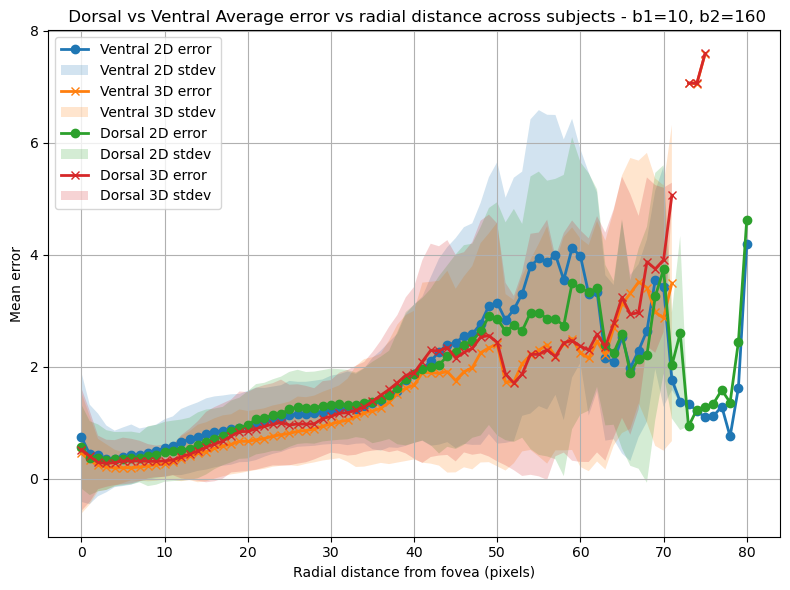

In [20]:
#ventral vs dorsal error analysis (2d vs 3d)
plt.figure(1, figsize=(8,6))

# plt.plot(np.where(valid)[0], group_mean_2d[valid], '-o', lw=2)
plt.plot(group_mean_2d_ventral, '-o', lw=2)
plt.xlabel('Radial distance from fovea (pixels)')
plt.ylabel('Mean error')
plt.fill_between(np.arange(len(group_mean_2d_ventral)), group_mean_2d_ventral - group_std_2d_ventral, group_mean_2d_ventral + group_std_2d_ventral, alpha=0.2)

# plt.plot(np.where(valid)[0], group_mean_3d[valid], '-x', lw=2)
plt.plot(group_mean_2d_dorsal, '-x', lw=2)
plt.xlabel('Radial distance from fovea (pixels)')
plt.ylabel('Mean error')
plt.fill_between(np.arange(len(group_mean_2d_dorsal)), group_mean_2d_dorsal - group_std_2d_dorsal, group_mean_2d_dorsal + group_std_2d_dorsal, alpha=0.2)
# plt.title('Average error vs radial distance across subjects - b1=' + str(b1) + ', b2=' + str(b2))

# plt.figure(2, figsize=(8,6))
plt.plot(group_mean_3d_ventral, '-o', lw=2)
plt.xlabel('Radial distance from fovea (pixels)')
plt.ylabel('Mean error')
plt.fill_between(np.arange(len(group_mean_3d_ventral)), group_mean_3d_ventral - group_std_3d_ventral, group_mean_3d_ventral + group_std_3d_ventral, alpha=0.2)

# plt.plot(np.where(valid)[0], group_mean_3d[valid], '-x', lw=2)
plt.plot(group_mean_3d_dorsal, '-x', lw=2)
plt.xlabel('Radial distance from fovea (pixels)')
plt.ylabel('Mean error')
plt.fill_between(np.arange(len(group_mean_3d_dorsal)), group_mean_3d_dorsal - group_std_3d_dorsal, group_mean_3d_dorsal + group_std_3d_dorsal, alpha=0.2)
plt.legend(['Ventral 2D error', 'Ventral 2D stdev', 'Ventral 3D error', 'Ventral 3D stdev', 'Dorsal 2D error', 'Dorsal 2D stdev', 'Dorsal 3D error', 'Dorsal 3D stdev'])
plt.title(' Dorsal vs Ventral Average error vs radial distance across subjects - b1=' + str(b1) + ', b2=' + str(b2))

plt.grid(True)

plt.tight_layout()
plt.show()